<a href="https://colab.research.google.com/github/hectorjimenez12/CC5205_Proyecto/blob/main/Game_ClassificationCNNV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento 3 Proyecto Mineria de datos

In [1]:
import pandas as pd
import numpy as np
import random
import torch
from torch.utils.data import TensorDataset, DataLoader
from PIL import Image
from torchvision import datasets, models, transforms
import time
import copy

import json
import ast

seed =  3495 #5937261 #  #123456

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True


# Cargar datos y descargar imagenes utilizadas

In [2]:
#url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam.csv'
#dfdata = pd.read_csv(url)
#url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam_description_data.csv.zip'
#df_descriptions = pd.read_csv(url)
#url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam_media_data.csv.zip'
url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/SteamSpy_Filt_AllData.zip'
dfmedia = pd.read_csv(url)

In [3]:
dfmedia

,index,appid,name,owners,screenshots,priceclp
0,1,2870,X Rebirth,500000-1000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",15500.0
1,2,4720,Condemned: Criminal Origins,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",7500.0
2,3,4920,Natural Selection 2,1000000-2000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",3000.0
3,4,7800,Stubbs the Zombie in Rebel Without a Pulse,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",10500.0
4,6,8870,BioShock Infinite,5000000-10000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",14500.0
...,...,...,...,...,...,...
20798,27189,2559280,Drift Cars Zombie Crusher,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",434.0
20799,27190,2559980,I commissioned some ladybugs 2,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",2040.0
20800,27191,2561180,Rescue Team: Mineral of Miracles,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",3570.0
20801,27192,2562650,Agriculture Tractor Sim,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",871.0


In [4]:
#dfdata.groupby('owners').count().loc[:,'name'].sort_values().plot.bar()
#ELIMINAR LOS DE CLASE entre 100000 y 200000

dfmedia = dfmedia[~ dfmedia.owners.isin(['100000-200000']) ]
#dfmedia = dfmedia.reset_index(level=0,drop=True)
dfmedia

,index,appid,name,owners,screenshots,priceclp
0,1,2870,X Rebirth,500000-1000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",15500.0
1,2,4720,Condemned: Criminal Origins,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",7500.0
2,3,4920,Natural Selection 2,1000000-2000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",3000.0
3,4,7800,Stubbs the Zombie in Rebel Without a Pulse,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",10500.0
4,6,8870,BioShock Infinite,5000000-10000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",14500.0
...,...,...,...,...,...,...
20798,27189,2559280,Drift Cars Zombie Crusher,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",434.0
20799,27190,2559980,I commissioned some ladybugs 2,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",2040.0
20800,27191,2561180,Rescue Team: Mineral of Miracles,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",3570.0
20801,27192,2562650,Agriculture Tractor Sim,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",871.0


In [5]:
def class_owners(strowners):
  own_int = int(strowners.split('-')[0])
  if own_int > 100000:
    return 'Hsell'
  else:
    return 'Lsell'
class_owners(dfmedia.owners[2])

'Hsell'

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
import os


Mounted at /content/gdrive


Cambiar esto

In [ ]:
ids = os.listdir('/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes')

In [ ]:
#ids1 = [ int(i.split('.')[0].split('header')[1]) for i in ids if i[0:3] != 'add']
#ids2 = [ int(i.split('.')[0].split('add')[1]) for i in ids if i[0:3] == 'add']
#print(len(ids1),len(ids2))

In [ ]:
ids = [ int(i.split('.')[0].split('header')[1]) if i[0:3] != 'add' else int(i.split('.')[0].split('add')[1]) for i in ids]  #[i for i in ids1 if i in ids2]
dfmedia = dfmedia[dfmedia.appid.isin(ids)]
#Image.open('/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/add1046110.png')

<Axes: xlabel='owners_label'>

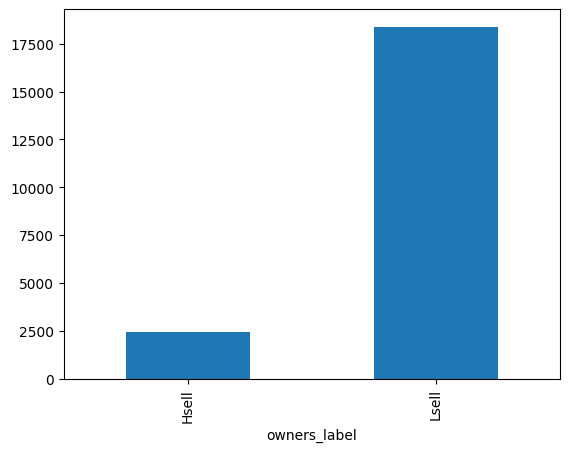

In [6]:
dfmedia['owners_label'] = [ class_owners(i) for i in dfmedia.owners ]
dfmedia.groupby('owners_label').count().loc[:,'name'].plot.bar()

Seleccionamos un sample de 500 por cada clase

In [ ]:
Nsample  = 1100
labels   = ['Hsell','Lsell']
list_ids = [ random.sample(list(dfmedia.index[dfmedia.owners_label.isin([i])]),k=Nsample) for i in labels ]
dfsample = dfmedia.loc[ sum(list_ids,[]) , ['appid','name','owners','owners_label','priceclp','screenshots'] ]
dfsample

,appid,name,owners,owners_label,priceclp,screenshots
3715,684450,Surviving the Aftermath,200000-500000,Hsell,28100.63,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
69,205230,Hell Yeah! Wrath of the Dead Rabbit,1000000-2000000,Hsell,7500.00,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
1101,367450,Poly Bridge,1000000-2000000,Hsell,1760.00,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
11479,1410710,Democracy 4,200000-500000,Hsell,4184.00,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
1605,420740,The Deed,200000-500000,Hsell,620.00,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
...,...,...,...,...,...,...
16470,1947110,PIPI IS YOU,0-20000,Lsell,500.00,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
7155,1036980,Mysteries of the Undead,0-20000,Lsell,3000.00,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
8373,1118950,Engineer Arena,0-20000,Lsell,1000.00,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
6544,1000800,Beetle Elf,0-20000,Lsell,11500.00,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."


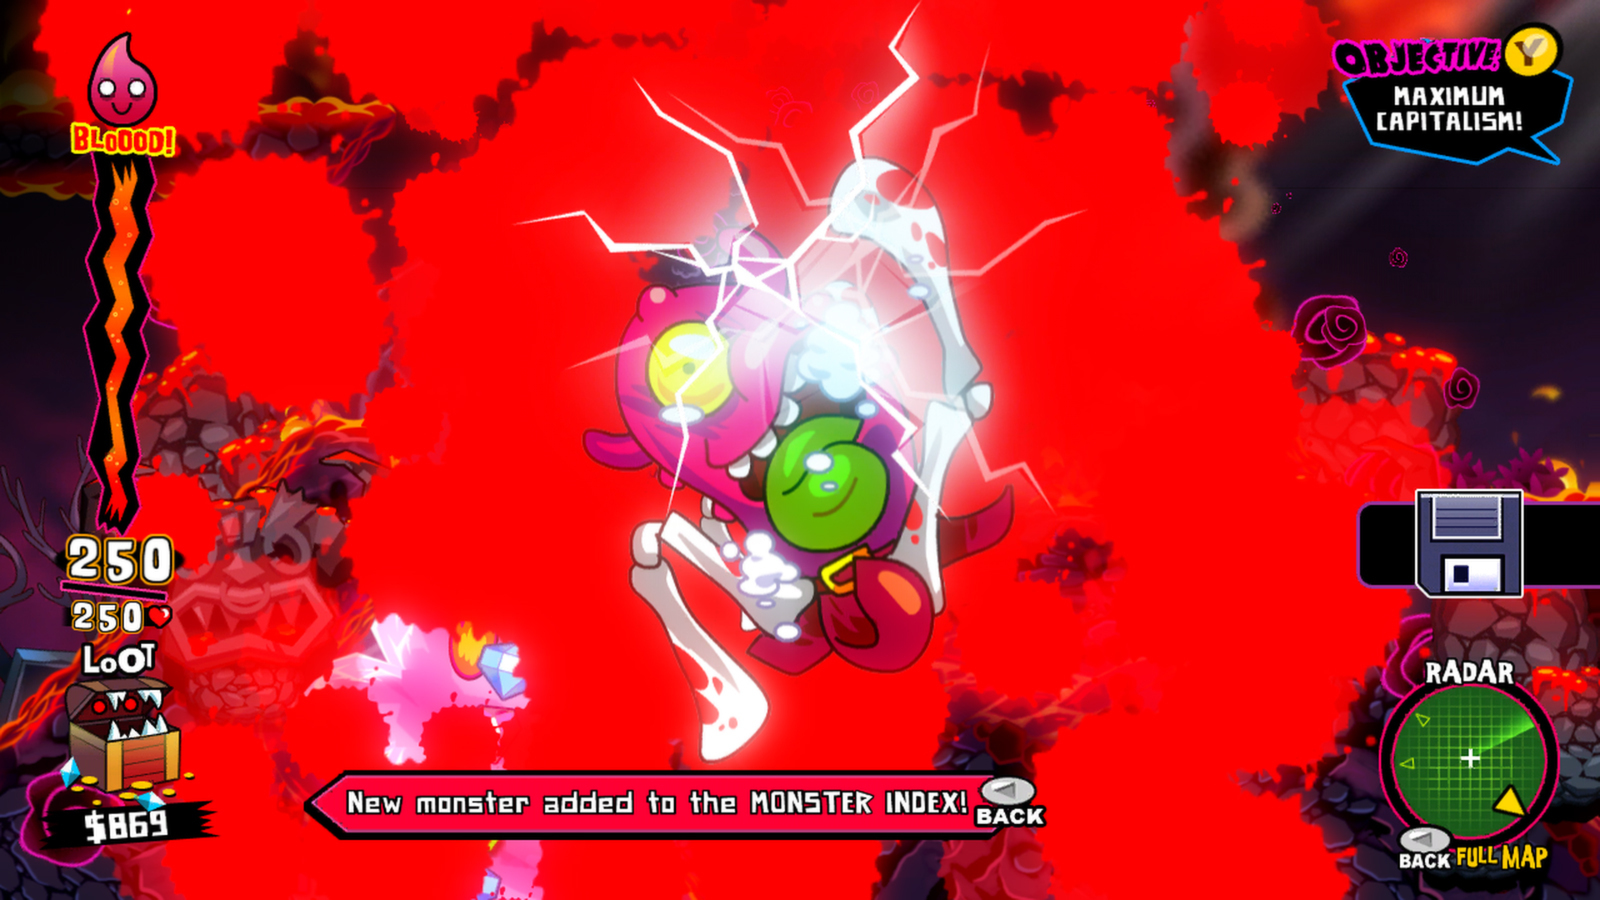

In [ ]:
Image.open('/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/add'+str(dfsample.appid.iloc[1])+'.png')

In [ ]:
#list_img = []
#for i in dfsample.appid:
#  #screenshots  = df_media['screenshots'][df_media.steam_appid.isin([i])]
#  screenshots  = dfsample['screenshots'][dfsample.appid.isin([i])]
#  screenshots2 = screenshots.iloc[0][1:-1]
#  screenshots3 = screenshots2.split('},')
#  screen_ds = [ast.literal_eval(idict+'}') if idict[-1] != '}' else ast.literal_eval(idict) for idict in screenshots3 ]

#  aditional_image = random.sample(screen_ds,1)
#  !wget -O 'add.png' {aditional_image[0]['path_full']}
#  !wget https://cdn.cloudflare.steamstatic.com/steam/apps/{i}/header.jpg
#  add_im = Image.open('add.png')
#  list_img.append( [ Image.open('header.jpg') ,copy.deepcopy(add_im)] )
#  !rm header.jpg
#  #!rm add.png

#list_img[20]

# 1 Definicion de clases y transformaciones


In [ ]:
import torchvision
class GamesDataset(torch.utils.data.Dataset):
  def __init__(self,root , appids, prices, labels, transform):
    self.transform = transform
    self.root = root
    self.class2idx = dict()
    self.class2idx['Lsell'] = 0
    self.class2idx['Hsell'] = 1
    self.classes = ['Lsell','Hsell']
    self.labels = labels
    self.prices = prices

    self.header_images = []
    self.add_images  = []

    for id_image in appids:
      self.header_images.append(self.root + 'header'  + str(id_image) +'.jpg')
      self.add_images.append(self.root + 'add'  + str(id_image) +'.png')

  def __len__(self):
    return len(self.header_images)

  def __getitem__(self, idx):
    header = Image.open( self.header_images[idx] ).convert('RGB')
    add = Image.open( self.add_images[idx] ).convert('RGB')
    label = self.class2idx[self.labels[idx]]

    if self.transform:
      header = self.transform(header)
      add    = self.transform(add)

    return header, add, torch.tensor(self.prices[idx],dtype = torch.float32 ), label

In [ ]:
transforms = torchvision.transforms.Compose([torchvision.transforms.Resize(100),
                                             torchvision.transforms.CenterCrop(160),
                                             torchvision.transforms.ToTensor() ] )
#torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
#list_img = [i[1] for i in list_img]

Split dataset en train, validation y test

In [ ]:
from sklearn.model_selection import train_test_split
ylabel = list(dfsample['owners_label'])
appids_prices = np.array(dfsample.loc[:,['appid','priceclp']])
X_train, X_test, Y_train, Y_test = train_test_split( appids_prices , ylabel, test_size = 0.2, stratify = ylabel , random_state=seed)
#X_train, X_val , Y_train, Y_val  = train_test_split(X_train, Y_train, test_size=10/80, stratify= Y_train, random_state=seed)

In [ ]:
#ipos = 556
#print(dfsample.iloc[ipos])
#print(ylabel[ipos])
#list_img[ipos][0]

In [ ]:
# crear Games datasets
train_dataset = GamesDataset(root='/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/',
                             appids = X_train[:,0].astype(int) , prices= X_train[:,1].astype(int),
                             labels = Y_train , transform = transforms)
#valid_dataset = GamesDataset(root='/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/',
#                             appids = X_val[:,0].astype(int) , prices= X_val[:,1].astype(int),
#                             labels = Y_val , transform = transforms)
test_dataset  = GamesDataset(root='/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/',
                             appids = X_test[:,0].astype(int) , prices= X_test[:,1].astype(int),
                             labels = Y_test , transform = transforms)
# dataloaders
batch_size = 20

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
#valid_loader = DataLoader(valid_dataset, shuffle=True, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, shuffle=False, batch_size=1)

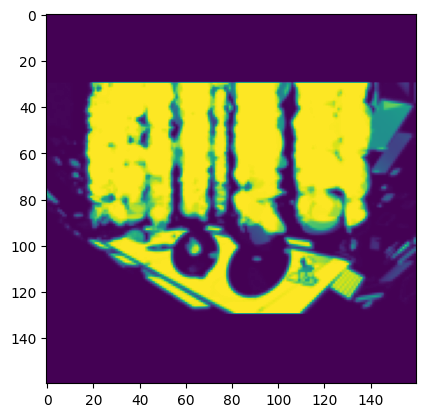

In [ ]:
import matplotlib.pyplot as plt
for header, add, price, test_labels in train_loader:
    sample_header = header[0]    # Reshape them according to your needs.
    sample_add = add[0]

#sample_image.shape
plt.imshow(sample_header.to('cpu').numpy()[2,:,:])
plt.imshow(sample_add.to('cpu').numpy()[2,:,:])

In [ ]:
train_on_gpu=torch.cuda.is_available()
if(train_on_gpu):
    print('Training on GPU.')
else:
    print('No GPU available, training on CPU.')

Training on GPU.


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# 3. CNN neural model

Basic convolution

In [ ]:
import torchsummary as ts
from torch.nn import Module, Sequential, LeakyReLU, Conv2d, BatchNorm2d, AvgPool2d, MaxPool2d, AdaptiveAvgPool2d, Linear
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
num_epochs = 10
momentum = 0.9
log_interval = 30
learning_rate=0.001

In [ ]:
class MLP(nn.Module):
  def __init__(self, input_dim, output_dim,dlayers):
    super().__init__()
    self.nlayers = 2
    self.fc1 = nn.Linear(input_dim, list(dlayers.items())[0][1].weight.shape[1] ) #capa de entrada
    for iname,hlayer in dlayers.items(): # capas ocultas
      setattr(self,iname,hlayer)
      self.nlayers = self.nlayers+ 1
    setattr(self,'fc'+str(self.nlayers),nn.Linear(hlayer.weight.shape[0], output_dim)) # salida a funcion de activacion
  def forward(self, input):
    batch_size = input.shape[0]
    input = input.view(batch_size, -1)
    #print(input)
    next_input = F.relu(self.fc1(input))
    for ilayer in range(self.nlayers - 2):
      next_input = F.relu( getattr(self,'fc'+str(ilayer+2))(next_input) )
    y_pred =  getattr(self,'fc'+str(self.nlayers))(next_input)
    #print(y_pred)
    return y_pred

#MLP_model = MLP(input_dim = 1 , output_dim = 5,dlayers={'fc2':nn.Linear(50, 25)})
#MLP_model(input = torch.tensor([7],dtype = torch.float32 ))
#print(MLP_model)
#ts.summary(MLP_model.to(device), (1,1,1), device='cuda') #-1 representa el tamaño de batch


In [ ]:
class BasicConv2d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, **kwargs) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=3,padding = 1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3,padding = 1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, out_channels, kernel_size=3)
        self.bn3 = nn.BatchNorm2d(out_channels)
    def forward(self, x):
        x = F.relu(F.max_pool2d(self.bn1(self.conv1(x)) , 2) )
        x = F.relu( F.max_pool2d(self.bn2(self.conv2(x)) , 2) )
        return F.relu( self.bn3(self.conv3(x)) )

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.branch_header = BasicConv2d(3, 64, kernel_size=3, stride=1, padding=1)  # 160 --> 80 --> 40
    self.branch_add    = BasicConv2d(3, 64, kernel_size=3, stride=1, padding=1)  # 64 channels
    self.branch_price  = MLP(input_dim = 1 , output_dim = 5,dlayers={'fc2':nn.Linear(50, 25)}) #FCL
    self.fc1 = nn.Linear( 38*38*64*2 + 5 , 100) #"256"
    self.fc2 = nn.Linear(100,2)
    #self.sig = nn.Sigmoid()
  def forward(self, im1,im2,p):
    # header --> -1, 224/2 x 224/2 x 64, add--> -1, 224/2 x 224/2 x 64, price --> -1, 10
    outputs              = [self.branch_header(im1), self.branch_add(im2), self.branch_price(p)]
    #for i,out in enumerate(outputs):
    #  print(out.shape)
    #flattening and concat
    outputs[0] = outputs[0].view(-1, 38*38*64 )
    outputs[1] = outputs[1].view(-1, 38*38*64 )
    embedd_cat = torch.cat(outputs, 1) #
    #output = embedd_cat.view(-1, 10 )
    x = F.relu(self.fc1(embedd_cat))
    x = self.fc2(x)
    return x

model = Net()
model = model.to(device)
criterion = nn.CrossEntropyLoss() #nn.BCELoss()
optimizer = torch.optim.Adam( model.parameters(), lr=learning_rate)
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [ ]:
#https://pypi.org/project/torch-summary/
#print(network)
#ts.summary(network.to(device), [(3, 160, 160),(3, 160, 160),(1,1,1)] , device='cuda') #-1 representa el tamaño de batch

In [ ]:
def train_model(model, criterio, optimizer, scheduler, num_epochs = 25):
  since = time.time()

  best_model_wts = copy.deepcopy(model.state_dict())
  best_acc = 0.0

  for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    print('-' * 10)

    #Train model
    scheduler.step()
    model.train()

    running_loss = 0.0
    running_corrects = 0.0

    for batchId, (data1,data2,data3,labels) in enumerate(train_loader):
      data1 = data1.to(device)
      data2 = data2.to(device)
      data3 = data3.to(device)
      labels = labels.to(device)

      #inputs = inputs.to(device)
      #labels = labels.to(device)
      optimizer.zero_grad()

      outputs = model(data1,data2,data3)
      #_, preds = torch.max(outputs, 1)
      if batchId == 0:
        print(outputs)
        #print(preds)
        print(labels)
        #torch.max(outputs, 1)
        #print(outputs.squeeze())
        #print(torch.round(outputs.squeeze(),decimals=0))

      _, preds = torch.max(outputs, 1)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      #preds = torch.round(outputs.squeeze(),decimals=0)
      running_loss += loss.item() * data1.size(0)
      running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss /len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    print('Train Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

    #Validation
    #model.eval()
    #running_loss = 0.0
    #running_corrects = 0.0

    #for inputs, labels in test_loader:
    #  inputs = inputs.to(device)
    #  labels = labels.to(device)

    #  with torch.set_grad_enabled(False):
    #    outputs = model(inputs)
    #    _, preds = torch.max(outputs, 1)
    #    loss = criterion(outputs, labels)

    #  running_loss += loss.item() * inputs.size(0)
    #  running_corrects += torch.sum(preds == labels.data)

    #epoch_loss = running_loss /len(test_dataset)
    #epoch_acc = running_corrects.double() / len(test_dataset)

    #print('Val Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

    if epoch_acc > best_acc:
        best_acc = epoch_acc
        best_model_wts = copy.deepcopy(model.state_dict())

  time_elapsed = time.time() - since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60, time_elapsed % 60))
  print('Best val accucary: {:.4f}'.format(best_acc))

  model.load_state_dict(best_model_wts)
  return model

In [ ]:
#test(model)
train_model(model,criterio = criterion,optimizer= optimizer, scheduler= exp_lr_scheduler ,num_epochs=5)


Epoch 0/4
----------
tensor([[ -2.3947,   4.0723],
        [ -3.3139,  -0.9406],
        [  3.0788,  -9.7581],
        [  2.3617,  -5.5900],
        [  0.8314,  -2.0948],
        [ -0.9190,  -0.6179],
        [  4.4537, -11.3471],
        [ -2.5264,   3.6644],
        [  2.2645,  -5.0055],
        [  1.9943,  -5.6157],
        [  1.3338,  -4.8844],
        [ -2.9187,   0.4493],
        [ -3.3504,   3.8549],
        [ -2.1443,   3.3475],
        [  0.9365,  -3.0467],
        [  1.8103,  -6.5012],
        [ -2.0444,   3.5526],
        [ -1.5987,   1.3299],
        [  0.6269,  -2.9716],
        [ -1.3877,   2.4180]], device='cuda:0', grad_fn=<AddmmBackward0>)
tensor([1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1],
       device='cuda:0')
Train Loss: 0.0638 Acc: 0.9795
Epoch 1/4
----------
tensor([[  1.3433,  -2.5454],
        [ -1.5110,  11.0436],
        [ -1.6002,   0.2513],
        [ -4.2230,   4.5615],
        [  2.9231, -10.3601],
        [ -2.5809,   0.0565],
        [ 